# 나이브 베이스 분류기(Naive Bayes Classification)
*   베이스 정리를 적용한 확률적 분류 알고리즘
*   모든 특성들이 독립임을 가정 (naive가정)
*   입력 특성에 따라 3개의 분류기 존재
    *   가우시안 나이브 베이즈 분류기
    *   베르누이 나이브 베이즈 분류기
    *   다항 나이브 베이즈 분류기

# 나이브 베이즈 분류기의 확률 모델
*   나이브 베이즈는 조건부 확률 모델
*   N개의 특성을 나타내는 벡터 x를 입력받아 k개의 가능한 확률적 결과를 출력

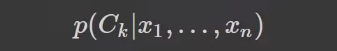

*   위의 식에 베이즈 정리를 적용하면 다음과 같음

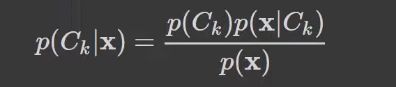

*   위의 식에서 분자만이 출력 값에 영향을 받기 때문에 분모 부분을 상수로 취급할 수 있음

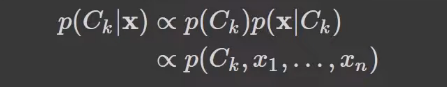

*   위의 식을 연쇄 법칙을 사용해 다음과 같이 쓸 수 있음

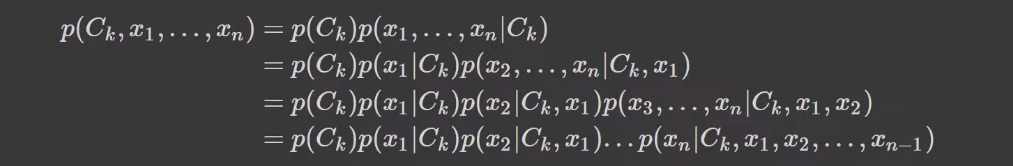

*   나이브 베이즈 분류기는 모든 특성이 독립이라고 가정하기 때문에 위의 식을 다음과 같이 쓸 수 있음

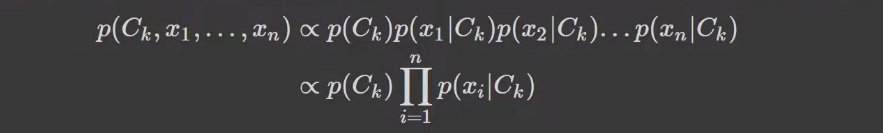

*   위의 식을 통해 나온 값들 중 가장 큰 값을 갖는 클래스가 예측 결과

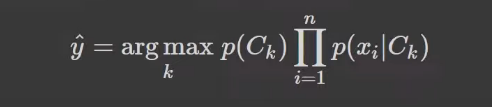

In [ ]:
### 라이브러리 임포트 및 환경 설정 :
### 머신러닝에 필요한 데이터 처리, 모델, 전처리 도구들을 불러오는 단계


import numpy as np  # 수치 계산 및 배열 처리를 위한 라이브러리
import pandas as pd # 데이터프레임 형식의 데이터 조작을 위한 라이브러리

# 나이브 베이즈 알고리즘 3종 (연속형, 이진형, 이산형 데이터용)
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB
# 분석에 사용할 데이터셋 (산림 토양 피복 유형, 20개의 뉴스그룹 텍스트 데이터)
from sklearn.datasets import fetch_covtype, fetch_20newsgroups
# 데이터를 학습용과 테스트용으로 분리하는 함수
from sklearn.model_selection import train_test_split
# 데이터 스케일링(정규화/표준화)을 위한 도구
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# 텍스트 데이터를 수치 벡터로 변환하는 도구들
from sklearn.feature_extraction.text import CountVectorizer, HashingVectorizer, TfidfVectorizer
# 모델 성능 평가를 위한 지표(정확도, F1-score 등) 모듈
from sklearn import metrics

In [ ]:
### 나이브 베이즈의 수학적 원리 시뮬레이션 :
### 사전 확률(Prior)과 우도(Likelihood)를 곱하여 사후 확률의 분자 값을 계산하는 과정


# 각 클래스가 발생할 사전 확률 (예: 4개의 클래스)
prior = [0.45, 0.3, 0.15, 0.1]
# 각 클래스 조건하에서 특징(Feature)들이 나타날 확률 (우도)
likelihood = [[0.3, 0.3, 0.4], [0.7, 0.2, 0.1], [0.15, 0.5, 0.35], [0.6, 0.2, 0.2]]

idx = 0
for c, xs in zip(prior, likelihood): # 각 클래스의 사전확률과 우도 리스트를 하나씩 꺼냄
    result = 1. # 확률 곱을 계산하기 위한 초기값

    for x in xs:
        result *= x # 모든 특징의 우도를 곱함 (조건부 독립 가정)
    result *= c # 최종적으로 사전 확률을 곱함 (P(A|B) ∝ P(B|A) * P(A))

    idx += 1
    print(f"{idx}번째 클래스의 가능성: {result}")

1번째 클래스의 가능성: 0.0162
2번째 클래스의 가능성: 0.0042
3번째 클래스의 가능성: 0.0039375
4번째 클래스의 가능성: 0.0024000000000000002


# 산림 토양 데이터

*   산림 지역 토양의 특징 데이터
*   토양이 어떤 종류에 속하는지 예측
*   https://archive.ics.uci.edu/ml/datasets/Covertype 에서 데이터의 자세한 설명 확인 가능

60만개 가까운 매우 큰 데이터 셋

In [ ]:
### 데이터셋 로드 및 탐색 :
### fetch_covtype 데이터를 불러오고 구조를 확인하는 단계


covtype = fetch_covtype() # 산림 피복 유형(Covertype) 데이터셋 다운로드/로드
print(covtype.DESCR)      # 데이터셋에 대한 상세 설명(출처, 변수 의미 등) 출력

.. _covtype_dataset:

Forest covertypes
-----------------

The samples in this dataset correspond to 30×30m patches of forest in the US,
collected for the task of predicting each patch's cover type,
i.e. the dominant species of tree.
There are seven covertypes, making this a multiclass classification problem.
Each sample has 54 features, described on the
`dataset's homepage <https://archive.ics.uci.edu/ml/datasets/Covertype>`__.
Some of the features are boolean indicators,
while others are discrete or continuous measurements.

**Data Set Characteristics:**

=================   ============
Classes                        7
Samples total             581012
Dimensionality                54
Features                     int
=================   ============

:func:`sklearn.datasets.fetch_covtype` will load the covertype dataset;
it returns a dictionary-like 'Bunch' object
with the feature matrix in the ``data`` member
and the target values in ``target``. If optional argument 'as_frame' is
se

7개의 클래스(토양의 분류)와 샘플수가 58만(581012)개이고 특징(피쳐)의 갯수도 54개로 매우 많다.

In [ ]:
### 데이터셋 로드 및 탐색 :
### fetch_covtype 데이터를 불러오고 구조를 확인하는 단계


# 데이터를 판다스 데이터프레임으로 변환하여 시각적으로 확인 (주석 처리된 부분)
# covtype.data는 독립 변수(특징값)들이 들어있는 행렬
#covtype.data
pd.DataFrame(covtype.data)

,0,1,2,3,4,5,6,7,8,9,...,44,45,46,47,48,49,50,51,52,53
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2785.0,155.0,18.0,242.0,118.0,3090.0,238.0,238.0,122.0,6211.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581007,2396.0,153.0,20.0,85.0,17.0,108.0,240.0,237.0,118.0,837.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
581008,2391.0,152.0,19.0,67.0,12.0,95.0,240.0,237.0,119.0,845.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
581009,2386.0,159.0,17.0,60.0,7.0,90.0,236.0,241.0,130.0,854.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
581010,2384.0,170.0,15.0,60.0,5.0,90.0,230.0,245.0,143.0,864.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
### 데이터셋 로드 및 탐색 :
### fetch_covtype 데이터를 불러오고 구조를 확인하는 단계


# 타겟(정답) 데이터 확인 (1~7 사이의 산림 유형 클래스)
covtype.target

array([5, 5, 2, ..., 3, 3, 3], dtype=int32)

## 학습, 평가 데이터 분류

In [ ]:
### 데이터 분할 (Train/Test Split) :
### 모델의 일반화 성능을 측정하기 위해 데이터를 나누는 중요한 작업


# 독립 변수(X)와 종속 변수(y) 설정
covtype_X = covtype.data
covtype_y = covtype.target

In [ ]:
### 데이터 분할 (Train/Test Split) :
### 모델의 일반화 성능을 측정하기 위해 데이터를 나누는 중요한 작업


# 전체 데이터를 학습용(80%)과 평가용(20%)으로 분리
# random_state는 코드 실행 시마다 동일한 분할을 유지하기 위한 고유 번호
covtype_X_train, covtype_X_test, covtype_y_train, covtype_y_test = train_test_split(
    covtype_X, covtype_y, test_size=0.2, random_state=123
)

In [ ]:
### 데이터 분할 (Train/Test Split) :
### 모델의 일반화 성능을 측정하기 위해 데이터를 나누는 중요한 작업


# 분할된 데이터의 형태(Shape)를 출력하여 크기 확인
print('전체 데이터 크기: {}'.format(covtype_X.shape))
print('학습 데이터 크기: {}'.format(covtype_X_train.shape))
print('평가 데이터 크기: {}'.format(covtype_X_test.shape))

전체 데이터 크기: (581012, 54)
학습 데이터 크기: (464809, 54)
평가 데이터 크기: (116203, 54)


## 전처리

### 전처리 전 데이터

In [ ]:
### 데이터 통계 요약 :
### 분할된 데이터들의 분포(평균, 표준편차 등)를 확인하여 스케일링 필요성을 판단


# 전체 데이터의 기초 통계량 확인
covtype_df = pd.DataFrame(data=covtype_X)
covtype_df.describe() # 개수, 평균, 표준편차, 사분위수 등 출력

,0,1,2,3,4,5,6,7,8,9,...,44,45,46,47,48,49,50,51,52,53
count,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,...,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000
mean,2959.365301,155.656807,14.103704,269.428217,46.418855,2350.146611,212.146049,223.318716,142.528263,1980.291226,...,0.044175,0.090392,0.077716,0.002773,0.003255,0.000205,0.000513,0.026803,0.023762,0.015060
std,279.984734,111.913721,7.488242,212.549356,58.295232,1559.254870,26.769889,19.768697,38.274529,1324.195210,...,0.205483,0.286743,0.267725,0.052584,0.056957,0.014310,0.022641,0.161508,0.152307,0.121791
min,1859.000000,0.000000,0.000000,0.000000,-173.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2809.000000,58.000000,9.000000,108.000000,7.000000,1106.000000,198.000000,213.000000,119.000000,1024.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2996.000000,127.000000,13.000000,218.000000,30.000000,1997.000000,218.000000,226.000000,143.000000,1710.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3163.000000,260.000000,18.000000,384.000000,69.000000,3328.000000,231.000000,237.000000,168.000000,2550.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,3858.000000,360.000000,66.000000,1397.000000,601.000000,7117.000000,254.000000,254.000000,254.000000,7173.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
### 데이터 통계 요약 :
### 분할된 데이터들의 분포(평균, 표준편차 등)를 확인하여 스케일링 필요성을 판단


# 학습 데이터의 기초 통계량 확인
covtype_train_df = pd.DataFrame(data=covtype_X_train)
covtype_train_df.describe()

,0,1,2,3,4,5,6,7,8,9,...,44,45,46,47,48,49,50,51,52,53
count,464809.000000,464809.000000,464809.000000,464809.000000,464809.000000,464809.000000,464809.000000,464809.000000,464809.000000,464809.000000,...,464809.000000,464809.000000,464809.000000,464809.000000,464809.000000,464809.000000,464809.000000,464809.000000,464809.000000,464809.00000
mean,2959.583954,155.773737,14.105232,269.511550,46.413970,2349.586712,212.133689,223.324226,142.543516,1979.433311,...,0.044274,0.090267,0.077856,0.002775,0.003317,0.000209,0.000508,0.026798,0.023793,0.01518
std,280.059187,111.911361,7.493073,212.600131,58.314743,1559.862831,26.799839,19.774023,38.288420,1324.050205,...,0.205704,0.286564,0.267945,0.052608,0.057502,0.014445,0.022527,0.161493,0.152403,0.12227
min,1859.000000,0.000000,0.000000,0.000000,-166.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2810.000000,58.000000,9.000000,108.000000,7.000000,1104.000000,198.000000,213.000000,119.000000,1024.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,2996.000000,127.000000,13.000000,218.000000,30.000000,1995.000000,218.000000,226.000000,143.000000,1710.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,3164.000000,261.000000,18.000000,384.000000,69.000000,3327.000000,231.000000,237.000000,168.000000,2550.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,3858.000000,360.000000,66.000000,1397.000000,601.000000,7116.000000,254.000000,254.000000,254.000000,7173.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [ ]:
### 데이터 통계 요약 :
### 분할된 데이터들의 분포(평균, 표준편차 등)를 확인하여 스케일링 필요성을 판단


# 테스트 데이터의 기초 통계량 확인 (학습 데이터와 분포가 유사한지 체크)
covtype_test_df = pd.DataFrame(data=covtype_X_test)
covtype_test_df.describe()

,0,1,2,3,4,5,6,7,8,9,...,44,45,46,47,48,49,50,51,52,53
count,116203.000000,116203.000000,116203.000000,116203.000000,116203.000000,116203.000000,116203.000000,116203.000000,116203.000000,116203.000000,...,116203.000000,116203.000000,116203.000000,116203.000000,116203.000000,116203.000000,116203.000000,116203.000000,116203.000000,116203.000000
mean,2958.490693,155.189092,14.097588,269.094886,46.438397,2352.386195,212.195485,223.296679,142.467251,1983.722864,...,0.043777,0.090893,0.077158,0.002762,0.003003,0.000189,0.000534,0.026824,0.023640,0.014578
std,279.686220,111.922422,7.468915,212.346719,58.217367,1556.825356,26.649808,19.747450,38.219020,1324.775211,...,0.204599,0.287458,0.266843,0.052486,0.054721,0.013758,0.023093,0.161569,0.151924,0.119856
min,1860.000000,0.000000,0.000000,0.000000,-173.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2808.000000,58.000000,9.000000,108.000000,7.000000,1110.000000,198.000000,213.000000,119.000000,1024.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2995.000000,126.000000,13.000000,218.000000,30.000000,2002.000000,218.000000,226.000000,143.000000,1714.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3163.000000,259.000000,18.000000,390.000000,69.000000,3330.000000,231.000000,237.000000,168.000000,2553.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,3858.000000,360.000000,65.000000,1382.000000,598.000000,7117.000000,254.000000,254.000000,254.000000,7172.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 전처리 과정

In [ ]:
### StandardScaler를 이용한 데이터 표준화 :
### 데이터의 각 특성(Feature)이 평균 0, 표준편차 1이 되도록 변환하는 과정입니다.
### 이는 특정 변수의 값이 너무 커서 모델이 그 변수에만 과도하게 영향을 받는 것을 방지합니다.


# 1. StandardScaler 객체 생성
# 데이터를 평균 0, 표준편차 1의 표준정규분포 형태로 변환하기 위한 도구입니다.
scaler = StandardScaler()

# 2. 학습 데이터(Train Data)에 대해 fit과 transform을 동시에 수행
# fit: 학습 데이터의 평균(mean)과 표준편차(std)를 계산하여 저장합니다.
# transform: 계산된 평균과 표준편차를 바탕으로 데이터를 실제 변환합니다.
covtype_X_train_scale = scaler.fit_transform(covtype_X_train)

# 3. 평가 데이터(Test Data)에 대해 transform 수행
# 중요: 테스트 데이터는 학습 시 사용되지 않은 '새로운 데이터'여야 하므로,
# 반드시 '학습 데이터의 평균과 표준편차'를 그대로 사용하여 변환해야 합니다. (fit을 다시 하지 않음)
covtype_X_test_scale = scaler.transform(covtype_X_test)

## 전처리 후 데이터

*   평균은 0에 가깝게, 표준편차는 1에 가깝게 정규화

In [ ]:
### 변환된 학습 데이터 확인 :
### 스케일링이 적용된 넘파이(Numpy) 배열을 다시 판다스(Pandas) 데이터프레임으로 변환하여 통계치를 확인


# 변환된 학습 데이터를 데이터프레임 형식으로 생성
covtype_train_df = pd.DataFrame(data=covtype_X_train_scale)

# 학습 데이터의 기초 통계량 확인
# 변환이 잘 되었다면 모든 열의 mean(평균)은 0에 가깝고, std(표준편차)는 1에 가까워야 합니다.
covtype_train_df.describe()

,0,1,2,3,4,5,6,7,8,9,...,44,45,46,47,48,49,50,51,52,53
count,4.648090e+05,4.648090e+05,4.648090e+05,4.648090e+05,4.648090e+05,4.648090e+05,4.648090e+05,4.648090e+05,4.648090e+05,4.648090e+05,...,4.648090e+05,4.648090e+05,4.648090e+05,4.648090e+05,4.648090e+05,4.648090e+05,4.648090e+05,4.648090e+05,4.648090e+05,4.648090e+05
mean,2.201600e-16,-9.126201e-17,1.179527e-16,1.045615e-16,-2.189065e-17,3.363089e-17,-8.253326e-17,-5.665582e-16,5.810501e-17,-2.424481e-17,...,-3.097099e-17,-2.062949e-17,-7.151150e-17,-8.208994e-18,-8.560590e-18,2.782192e-18,2.568177e-18,3.205635e-17,7.949119e-19,-6.620699e-17
std,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,...,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00
min,-3.929831e+00,-1.391940e+00,-1.882438e+00,-1.267694e+00,-3.642547e+00,-1.506279e+00,-7.915492e+00,-1.129383e+01,-3.722892e+00,-1.494985e+00,...,-2.152327e-01,-3.149982e-01,-2.905665e-01,-5.275469e-02,-5.769345e-02,-1.444754e-02,-2.253871e-02,-1.659398e-01,-1.561168e-01,-1.241548e-01
25%,-5.341161e-01,-8.736722e-01,-6.813277e-01,-7.596972e-01,-6.758842e-01,-7.985241e-01,-5.273802e-01,-5.221111e-01,-6.148998e-01,-7.215998e-01,...,-2.152327e-01,-3.149982e-01,-2.905665e-01,-5.275469e-02,-5.769345e-02,-1.444754e-02,-2.253871e-02,-1.659398e-01,-1.561168e-01,-1.241548e-01
50%,1.300300e-01,-2.571121e-01,-1.475007e-01,-2.422934e-01,-2.814723e-01,-2.273194e-01,2.188937e-01,1.353178e-01,1.192227e-02,-2.034920e-01,...,-2.152327e-01,-3.149982e-01,-2.905665e-01,-5.275469e-02,-5.769345e-02,-1.444754e-02,-2.253871e-02,-1.659398e-01,-1.561168e-01,-1.241548e-01
75%,7.299038e-01,9.402654e-01,5.197830e-01,5.385160e-01,3.873129e-01,6.266027e-01,7.039718e-01,6.916038e-01,6.648619e-01,4.309257e-01,...,-2.152327e-01,-3.149982e-01,-2.905665e-01,-5.275469e-02,-5.769345e-02,-1.444754e-02,-2.253871e-02,-1.659398e-01,-1.561168e-01,-1.241548e-01
max,3.207954e+00,1.824895e+00,6.925706e+00,5.303335e+00,9.510230e+00,3.055665e+00,1.562187e+00,1.551318e+00,2.910974e+00,3.922489e+00,...,4.646135e+00,3.174622e+00,3.441553e+00,1.895566e+01,1.733299e+01,6.921593e+01,4.436812e+01,6.026282e+00,6.405461e+00,8.054458e+00


In [ ]:
### 변환된 평가 데이터 확인 :
### 평가 데이터 역시 동일한 기준으로 변환되었는지 통계 수치를 통해 검증


# 변환된 평가 데이터를 데이터프레임 형식으로 생성
covtype_test_df = pd.DataFrame(data=covtype_X_test_scale)

# 평가 데이터의 기초 통계량 확인
# 학습 데이터의 기준을 따랐으므로 평균이 정확히 0이 아닐 수 있지만, 비슷한 범주 안에 있게 됩니다.
covtype_test_df.describe()

,0,1,2,3,4,5,6,7,8,9,...,44,45,46,47,48,49,50,51,52,53
count,116203.000000,116203.000000,116203.000000,116203.000000,116203.000000,116203.000000,116203.000000,116203.000000,116203.000000,116203.000000,...,116203.000000,116203.000000,116203.000000,116203.000000,116203.000000,116203.000000,116203.000000,116203.000000,116203.000000,116203.000000
mean,-0.003904,-0.005224,-0.001020,-0.001960,0.000419,0.001795,0.002306,-0.001393,-0.001992,0.003240,...,-0.002417,0.002183,-0.002603,-0.000246,-0.005463,-0.001341,0.001146,0.000159,-0.001003,-0.004928
std,0.998669,1.000100,0.996777,0.998809,0.998331,0.998054,0.994403,0.998657,0.998189,1.000549,...,0.994631,1.003118,0.995891,0.997679,0.951633,0.952489,1.025096,1.000469,0.996864,0.980259
min,-3.926260,-1.391940,-1.882438,-1.267694,-3.762585,-1.506279,-7.915492,-11.293831,-3.722892,-1.494985,...,-0.215233,-0.314998,-0.290567,-0.052755,-0.057693,-0.014448,-0.022539,-0.165940,-0.156117,-0.124155
25%,-0.541257,-0.873672,-0.681328,-0.759697,-0.675884,-0.794678,-0.527380,-0.522111,-0.614900,-0.721600,...,-0.215233,-0.314998,-0.290567,-0.052755,-0.057693,-0.014448,-0.022539,-0.165940,-0.156117,-0.124155
50%,0.126459,-0.266048,-0.147501,-0.242293,-0.281472,-0.222832,0.218894,0.135318,0.011922,-0.200471,...,-0.215233,-0.314998,-0.290567,-0.052755,-0.057693,-0.014448,-0.022539,-0.165940,-0.156117,-0.124155
75%,0.726333,0.922394,0.519783,0.566738,0.387313,0.628526,0.703972,0.691604,0.664862,0.433192,...,-0.215233,-0.314998,-0.290567,-0.052755,-0.057693,-0.014448,-0.022539,-0.165940,-0.156117,-0.124155
max,3.207954,1.824895,6.792250,5.232780,9.458785,3.056306,1.562187,1.551318,2.910974,3.921734,...,4.646135,3.174622,3.441553,18.955660,17.332990,69.215933,44.368115,6.026282,6.405461,8.054458


# 20 Newsgroup 데이터
*   뉴스 기사가 어느 그룹에 속하는지 분류
*   뉴스 기사는 텍스트 데이터이기 때문에 특별한 전처리 과정이 필요

In [ ]:
### 20 Newsgroups 데이터셋 로드 :
### 20개의 서로 다른 주제(종교, 자동차, 과학 등)를 가진 뉴스그룹 포스트 데이터셋을 불러오는 과정


# 20 Newsgroups 데이터셋 다운로드 및 로드
newsgroup = fetch_20newsgroups()
# 데이터셋의 상세 정보(출처, 클래스 개수, 특징 등)를 출력하여 구조 파악
print(newsgroup.DESCR)

.. _20newsgroups_dataset:

The 20 newsgroups text dataset
------------------------------

The 20 newsgroups dataset comprises around 18000 newsgroups posts on
20 topics split in two subsets: one for training (or development)
and the other one for testing (or for performance evaluation). The split
between the train and test set is based upon a messages posted before
and after a specific date.

This module contains two loaders. The first one,
:func:`sklearn.datasets.fetch_20newsgroups`,
returns a list of the raw texts that can be fed to text feature
extractors such as :class:`~sklearn.feature_extraction.text.CountVectorizer`
with custom parameters so as to extract feature vectors.
The second one, :func:`sklearn.datasets.fetch_20newsgroups_vectorized`,
returns ready-to-use features, i.e., it is not necessary to use a feature
extractor.

**Data Set Characteristics:**

=================   ==========
Classes                     20
Samples total            18846
Dimensionality               1

정답 클래스 갯수 20개(분류 그룹), 전체 기사(article) 갯수는 18846개, 그리고 기사가 어떤 클래스냐를 분류하는 것이니 추가적인 차원이 없고 1개만 text데이터 형태로 있는것이다.

클래스 분류는 'alt.atheism',
     'comp.graphics',
     'comp.os.ms-windows.misc',
     'comp.sys.ibm.pc.hardware',
     'comp.sys.mac.hardware',
     'comp.windows.x',
     'misc.forsale',
     'rec.autos',
     'rec.motorcycles',
     'rec.sport.baseball',
     'rec.sport.hockey',
     'sci.crypt',
     'sci.electronics',
     'sci.med',
     'sci.space',
     'soc.religion.christian',
     'talk.politics.guns',
     'talk.politics.mideast',
     'talk.politics.misc',
     'talk.religion.misc'으로 분류된다.

In [ ]:
### 20 Newsgroups 데이터셋 로드 :
### 20개의 서로 다른 주제(종교, 자동차, 과학 등)를 가진 뉴스그룹 포스트 데이터셋을 불러오는 과정


# 데이터셋에 포함된 실제 텍스트 내용들을 확인 (리스트 형태)
newsgroup.data

["From: lerxst@wam.umd.edu (where's my thing)\nSubject: WHAT car is this!?\nNntp-Posting-Host: rac3.wam.umd.edu\nOrganization: University of Maryland, College Park\nLines: 15\n\n I was wondering if anyone out there could enlighten me on this car I saw\nthe other day. It was a 2-door sports car, looked to be from the late 60s/\nearly 70s. It was called a Bricklin. The doors were really small. In addition,\nthe front bumper was separate from the rest of the body. This is \nall I know. If anyone can tellme a model name, engine specs, years\nof production, where this car is made, history, or whatever info you\nhave on this funky looking car, please e-mail.\n\nThanks,\n- IL\n   ---- brought to you by your neighborhood Lerxst ----\n\n\n\n\n",
 "From: guykuo@carson.u.washington.edu (Guy Kuo)\nSubject: SI Clock Poll - Final Call\nSummary: Final call for SI clock reports\nKeywords: SI,acceleration,clock,upgrade\nArticle-I.D.: shelley.1qvfo9INNc3s\nOrganization: University of Washington\nLines: 

In [ ]:
### 20 Newsgroups 데이터셋 로드 :
### 20개의 서로 다른 주제(종교, 자동차, 과학 등)를 가진 뉴스그룹 포스트 데이터셋을 불러오는 과정


# 분류될 20개 주제(클래스)의 실제 이름을 확인 (예: 'alt.atheism', 'sci.space' 등)
newsgroup.target_names

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

## 학습, 평가 데이터 분류

In [ ]:
### 학습 및 평가 데이터 분리 :
### 텍스트 데이터는 처음부터 학습용(train)과 평가용(test) 데이터가 구분되어 제공되는 경우가 많습니다.


# subset 인자를 사용하여 학습용 데이터와 평가용 데이터를 각각 불러옴
newsgroup_train = fetch_20newsgroups(subset='train')
newsgroup_test = fetch_20newsgroups(subset='test')

In [ ]:
### 학습 및 평가 데이터 분리 :
### 텍스트 데이터는 처음부터 학습용(train)과 평가용(test) 데이터가 구분되어 제공되는 경우가 많습니다.


# 학습용 데이터의 본문(X)과 정답 라벨(y)을 변수에 할당
X_train, y_train = newsgroup_train.data, newsgroup_train.target
# 평가용 데이터의 본문(X)과 정답 라벨(y)을 변수에 할당
X_test, y_test = newsgroup_test.data, newsgroup_test.target

## 벡터화

*   텍스트 데이터는 기계학습 모델에 입력 할 수 없음
*   벡터화는 텍스트 데이터를 실수 벡터로 변환해 기계학습 모델에 입력 할 수 있도록 하는 전처리 과정
*   Scikit-learn 에서는 Count, Tf-idf(대표적으로 자주쓰임), Hashing 세가지 방법을 지원

## CountVectorizer
*   문서에 나온 단어의 수를 세서 벡터 생성

In [ ]:
### CountVectorizer를 이용한 텍스트 벡터화 :
### 컴퓨터는 '글자' 자체를 계산할 수 없으므로, 문장을 단어의 출현 빈도를 나타내는 숫자로 바꾸어야 합니다.
### 이 기법을 Bag of Words(BoW)라고 합니다.


# 1. CountVectorizer 객체 생성
# 문장을 토큰화하고 각 단어의 빈도를 세어 행렬로 변환하는 도구입니다.
count_vectorizer = CountVectorizer()

In [ ]:
### CountVectorizer를 이용한 텍스트 벡터화 :
### 컴퓨터는 '글자' 자체를 계산할 수 없으므로, 문장을 단어의 출현 빈도를 나타내는 숫자로 바꾸어야 합니다.
### 이 기법을 Bag of Words(BoW)라고 합니다.


# 2. 학습 데이터를 기반으로 단어 사전을 만들고(fit), 빈도 행렬로 변환(transform)
# fit: X_train에 나온 모든 단어를 파악하여 고유 번호(인덱스)를 부여합니다.
# transform: 각 문장에 어떤 단어가 몇 번 나왔는지 숫자로 채웁니다.
X_train_count = count_vectorizer.fit_transform(X_train)

# 3. 평가 데이터 변환
# 주의: 학습 데이터에서 만든 단어 사전만을 사용하여 변환해야 모델 평가가 정확합니다.
X_test_count = count_vectorizer.transform(X_test)

데이터를 희소 행렬 형태로 표현

In [ ]:
### 결과 확인 및 희소 행렬(Sparse Matrix) 이해 :
### 텍스트 데이터는 단어 종류는 매우 많지만, 한 문장에 쓰이는 단어는 소수이기에 대부분 0으로 채워진 '희소 행렬' 형태를 띱니다.


# 변환된 행렬의 형태(문장 수 x 단어 사전 크기)와 데이터 타입 확인
# 결과는 보통 (문장 수, 전체 단어 수) 형태의 희소 행렬로 출력됩니다.
X_train_count

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 1787565 stored elements and shape (11314, 130107)>

In [ ]:
### 결과 확인 및 희소 행렬(Sparse Matrix) 이해 :
### 텍스트 데이터는 단어 종류는 매우 많지만, 한 문장에 쓰이는 단어는 소수이기에 대부분 0으로 채워진 '희소 행렬' 형태를 띱니다.


# 첫 번째 뉴스 데이터(X_train_count[0])에 담긴 벡터 값을 출력
# 대부분의 값은 0이며, 단어가 존재하는 인덱스에만 빈도수가 표시됩니다.
for v in X_train_count[0]:
    print(v)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 89 stored elements and shape (1, 130107)>
  Coords	Values
  (0, 56979)	3
  (0, 75358)	2
  (0, 123162)	2
  (0, 118280)	2
  (0, 50527)	2
  (0, 124031)	2
  (0, 85354)	1
  (0, 114688)	1
  (0, 111322)	1
  (0, 123984)	1
  (0, 37780)	5
  (0, 68532)	3
  (0, 114731)	5
  (0, 87620)	1
  (0, 95162)	1
  (0, 64095)	1
  (0, 98949)	1
  (0, 90379)	1
  (0, 118983)	1
  (0, 89362)	3
  (0, 79666)	1
  (0, 40998)	1
  (0, 92081)	1
  (0, 76032)	1
  (0, 4605)	1
  :	:
  (0, 37565)	1
  (0, 113986)	1
  (0, 83256)	1
  (0, 86001)	1
  (0, 51730)	1
  (0, 109271)	1
  (0, 128026)	1
  (0, 96144)	1
  (0, 78784)	1
  (0, 63363)	1
  (0, 90252)	1
  (0, 123989)	1
  (0, 67156)	1
  (0, 128402)	2
  (0, 62221)	1
  (0, 57308)	1
  (0, 76722)	1
  (0, 94362)	1
  (0, 78955)	1
  (0, 114428)	1
  (0, 66098)	1
  (0, 35187)	1
  (0, 35983)	1
  (0, 128420)	1
  (0, 86580)	1


## HashingVectorizer
*   각 단어를 해쉬 값으로 표현
*   미리 정해진 크기의 벡터로 표현

In [ ]:
### HashingVectorizer: 메모리 효율적인 벡터화 :
### 단어 사전을 메모리에 생성하지 않고, 해시 함수를 이용해 고정된 크기의 벡터로 변환합니다. 대용량 데이터 처리에 유리합니다.


# 1. HashingVectorizer 객체 생성
# n_features=1000: 출력 벡터의 크기를 1000개로 고정합니다.
# 단어 종류가 아무리 많아도 1000개의 공간 안에 해시값으로 할당됩니다.
hash_vectorizer = HashingVectorizer(n_features=1000)

In [ ]:
### HashingVectorizer: 메모리 효율적인 벡터화 :
### 단어 사전을 메모리에 생성하지 않고, 해시 함수를 이용해 고정된 크기의 벡터로 변환합니다. 대용량 데이터 처리에 유리합니다.


# 2. 학습 데이터 변환 (Hashing은 별도의 사전 학습(fit)이 필요 없으나 관습적으로 사용)
X_train_hash = hash_vectorizer.fit_transform(X_train)

# 3. 평가 데이터 변환
X_test_hash = hash_vectorizer.transform(X_test)

In [ ]:
### HashingVectorizer: 메모리 효율적인 벡터화 :
### 단어 사전을 메모리에 생성하지 않고, 해시 함수를 이용해 고정된 크기의 벡터로 변환합니다. 대용량 데이터 처리에 유리합니다.


# 변환된 결과의 형태 확인 (행 개수 x 1000)
X_train_hash

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1550687 stored elements and shape (11314, 1000)>

In [ ]:
### HashingVectorizer: 메모리 효율적인 벡터화 :
### 단어 사전을 메모리에 생성하지 않고, 해시 함수를 이용해 고정된 크기의 벡터로 변환합니다. 대용량 데이터 처리에 유리합니다.


# 첫 번째 뉴스 데이터의 해시 변환 결과 출력
# 특정 인덱스에 할당된 값(일반적으로 -1~1 사이의 정규화된 값)들이 표시됩니다.
print(X_train_hash[0])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 85 stored elements and shape (1, 1000)>
  Coords	Values
  (0, 80)	-0.0642824346533225
  (0, 108)	0.0642824346533225
  (0, 111)	-0.128564869306645
  (0, 145)	0.0642824346533225
  (0, 158)	0.0642824346533225
  (0, 159)	-0.0642824346533225
  (0, 161)	0.0642824346533225
  (0, 165)	-0.0642824346533225
  (0, 171)	0.0642824346533225
  (0, 182)	0.0642824346533225
  (0, 195)	-0.0642824346533225
  (0, 196)	0.19284730395996752
  (0, 205)	-0.0642824346533225
  (0, 209)	0.0642824346533225
  (0, 234)	0.0642824346533225
  (0, 237)	0.0642824346533225
  (0, 248)	0.0642824346533225
  (0, 265)	0.19284730395996752
  (0, 274)	0.0642824346533225
  (0, 277)	0.19284730395996752
  (0, 284)	-0.0642824346533225
  (0, 286)	-0.0642824346533225
  (0, 296)	0.0642824346533225
  (0, 362)	-0.0642824346533225
  (0, 364)	-0.0642824346533225
  :	:
  (0, 739)	0.0
  (0, 761)	-0.0642824346533225
  (0, 766)	0.0642824346533225
  (0, 800)	-0.0642824346533225
  (0, 81

# TfidfVectorizer
*   문서에 나온 단어 빈도(term frequency)와 역문서 빈도(inverse document frequency)를 곱해서 구함
*   각 빈도는 일반적으로 로그 스케일링 후 사용

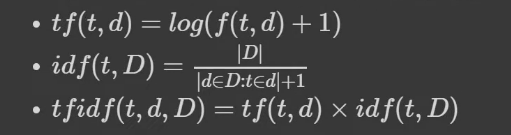

너무 빈번하게 나오는 단어는 스케일링을 해주는것

In [ ]:
### TfidfVectorizer: 단어의 중요도 반영 :
### 모든 문서에 흔하게 등장하는 단어(the, a, is 등)의 가중치는 낮추고,
### 특정 문서에만 자주 등장하는 핵심 단어의 가중치를 높이는 방식


# 1. TfidfVectorizer 객체 생성
# TF(단어 빈도)와 IDF(역문서 빈도)를 곱하여 수치화하는 도구입니다.
tfidf_vectorizer = TfidfVectorizer()

In [ ]:
### TfidfVectorizer: 단어의 중요도 반영 :
### 모든 문서에 흔하게 등장하는 단어(the, a, is 등)의 가중치는 낮추고,
### 특정 문서에만 자주 등장하는 핵심 단어의 가중치를 높이는 방식


# 2. 학습 데이터의 단어 중요도 학습 및 변환
# fit: 전체 문서에서 각 단어가 얼마나 희귀한지(IDF)를 계산합니다.
# transform: 계산된 가중치를 적용하여 행렬을 생성합니다.
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# 3. 평가 데이터 변환 (학습된 IDF 기준 적용)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [ ]:
### TfidfVectorizer: 단어의 중요도 반영 :
### 모든 문서에 흔하게 등장하는 단어(the, a, is 등)의 가중치는 낮추고,
### 특정 문서에만 자주 등장하는 핵심 단어의 가중치를 높이는 방식


# 변환된 TF-IDF 희소 행렬 구조 확인
X_train_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1787565 stored elements and shape (11314, 130107)>

In [ ]:
### TfidfVectorizer: 단어의 중요도 반영 :
### 모든 문서에 흔하게 등장하는 단어(the, a, is 등)의 가중치는 낮추고,
### 특정 문서에만 자주 등장하는 핵심 단어의 가중치를 높이는 방식


# 첫 번째 뉴스 데이터에 포함된 단어들의 TF-IDF 가중치 출력
# 단순히 빈도만 셌던 CountVectorizer와 달리 0.234, 0.112 같은 실수형 가중치가 나타납니다.
for v in X_train_tfidf[0]:
    print(v)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 89 stored elements and shape (1, 130107)>
  Coords	Values
  (0, 56979)	0.0574701540748513
  (0, 75358)	0.3538350134970617
  (0, 123162)	0.25970902457356887
  (0, 118280)	0.21186807208281694
  (0, 50527)	0.05461428658858725
  (0, 124031)	0.10798795154169123
  (0, 85354)	0.03696978508816317
  (0, 114688)	0.06214070986309587
  (0, 111322)	0.019156718024950434
  (0, 123984)	0.036854292634593756
  (0, 37780)	0.3813389125949312
  (0, 68532)	0.07325812342131598
  (0, 114731)	0.1444727551278406
  (0, 87620)	0.0356718631408158
  (0, 95162)	0.03447138409326312
  (0, 64095)	0.035420924271313554
  (0, 98949)	0.16068606055394935
  (0, 90379)	0.01992885995664587
  (0, 118983)	0.03708597805061915
  (0, 89362)	0.06521174306303765
  (0, 79666)	0.10936401252414275
  (0, 40998)	0.07801368196918111
  (0, 92081)	0.09913274493911224
  (0, 76032)	0.01921946305222309
  (0, 4605)	0.06332603952480324
  :	:
  (0, 37565)	0.03431760442478462
  (0, 11398

# 가우시안 나이브 베이즈
*   입력 특성이 가우시안(정규) 분포를 갖는다고 가정

In [ ]:
### 모델 생성 및 학습 :
### 가우시안 나이브 베이즈 모델을 생성하고 스케일링된 데이터를 학습


# 가우시안 나이브 베이즈 모델 객체 생성 (연속형 변수에 적합)
model = GaussianNB()

# 학습 데이터(X)와 정답(y)을 이용해 모델을 학습(fit)시킴
# 스케일링된 데이터를 사용하여 모델의 수렴 속도와 성능을 높임
model.fit(covtype_X_train_scale, covtype_y_train)

GaussianNB()

In [ ]:
### 학습 데이터(Train) 성능 평가 :
### 모델이 공부한 데이터에 대해 얼마나 잘 맞추는지 확인


# 학습된 모델로 학습 데이터의 정답을 예측
predict = model.predict(covtype_X_train_scale)

# 정확도(Accuracy) 계산: 전체 중 맞춘 비율
acc = metrics.accuracy_score(covtype_y_train, predict)

# F1-score 계산: 정밀도와 재현율의 조화 평균 (average=None은 클래스별 점수를 각각 보여줌)
f1 = metrics.f1_score(covtype_y_train, predict, average=None)

print('Train Accuracy: {}'.format(acc))
print('Train F1 score: {}'.format(f1))

Train Accuracy: 0.08790707580963364
Train F1 score: [0.04067997 0.01764508 0.33552838 0.13564023 0.04350963 0.07115838
 0.23376663]


In [ ]:
### 평가 데이터(Test) 성능 평가 :
### 모델이 처음 보는 데이터에 대해서도 일반화 성능을 잘 내는지 확인


# 학습된 모델로 테스트 데이터의 정답을 예측
predict = model.predict(covtype_X_test_scale)

# 테스트 데이터에 대한 정확도 및 F1-score 산출
acc = metrics.accuracy_score(covtype_y_test, predict)
f1 = metrics.f1_score(covtype_y_test, predict, average=None)

print('Test Accuracy: {}'.format(acc))
print('Test F1 score: {}'.format(f1))

Test Accuracy: 0.08817328296171355
Test F1 score: [0.03945161 0.01917044 0.33277969 0.14916019 0.04181445 0.07219899
 0.23537377]


In [ ]:
### 시각화 라이브러리 및 도구 준비 :
### 결정 경계를 그리기 위한 그래프 라이브러리와 가상 데이터 생성 도구를 불러옵니다.


import matplotlib.pyplot as plt # 그래프 그리기 도구
import seaborn as sns           # 그래프 스타일링 도구

# 그래프의 배경 스타일 설정 (흰색 격자 무늬)
#plt.style.use(['seaborn-whitegrid'])
plt.style.use(['seaborn-v0_8-whitegrid'])

# 가상의 데이터 덩어리(Blob)를 생성해주는 함수 임포트
from sklearn.datasets import make_blobs

In [ ]:
### 결정 경계 시각화 함수 정의 :
### 모델이 공간을 어떻게 나누고 있는지 색상으로 표시하기 위한 도우미 함수들입니다.


# 1. 격자망(Meshgrid) 생성 함수
# 데이터의 최소/최대값 범위를 찾아 촘촘한 좌표 점들을 만듭니다.
def make_meshgrid(x, y, h=.02):
    x_min, x_max = x.min()-1, x.max()+1
    y_min, y_max = y.min()-1, y.max()+1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    return xx, yy

# 2. 등고선(Contours) 그리기 함수
# 생성된 격자망의 모든 점에 대해 모델의 예측값을 채워 색깔로 영역을 구분합니다.
def plot_contours(clf, xx, yy, **params):
    # 격자 점들을 입력 데이터 형태로 변환 후 예측
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape) # 결과를 다시 격자 형태로 복구
    out = plt.contourf(xx, yy, Z, **params) # 영역을 색으로 칠함
    return out

In [ ]:
### 가상 데이터 생성 :
### 시각화 연습을 위해 무작위 데이터 1000개를 만듭니다.


# 3개의 중심점을 가진 1000개의 샘플 데이터 생성
X, y = make_blobs(n_samples=1000)

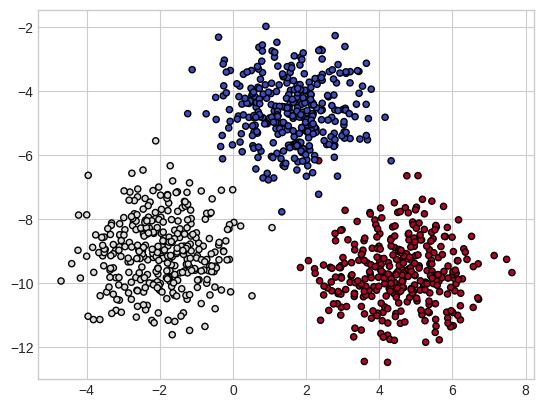

In [ ]:
### 산점도 확인


# 생성된 데이터를 산점도로 출력 (c=y는 클래스별로 색을 다르게 함)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=20, edgecolors='k');

In [ ]:
### 가상 데이터 모델 학습 :
### 가상의 데이터 덩어리들을 분류하도록 모델을 학습시킵니다.


# 가상의 데이터 X, y를 가우시안 나이브 베이즈 모델에 학습
model = GaussianNB()
model.fit(X, y)

GaussianNB()

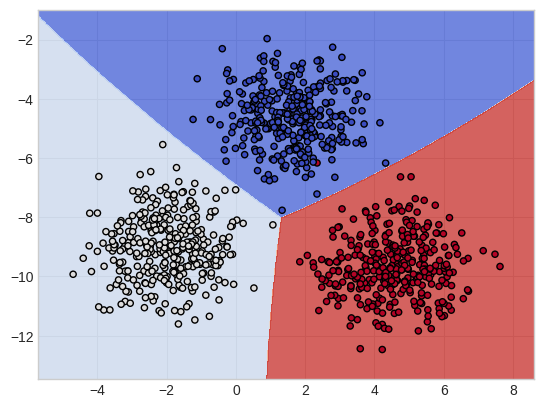

In [ ]:
### 결정 경계 결과 시각화 :
### 모델이 학습한 '기준'이 공간상에 어떻게 나타나는지 확인


# 1. 격자 좌표 생성
xx, yy = make_meshgrid(X[:, 0], X[:, 1])

# 2. 모델의 예측 영역을 색상으로 표시
plot_contours(model, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)

# 3. 그 위에 실제 데이터 점들을 뿌려서 얼마나 잘 분류됐는지 확인
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=20, edgecolors='k');

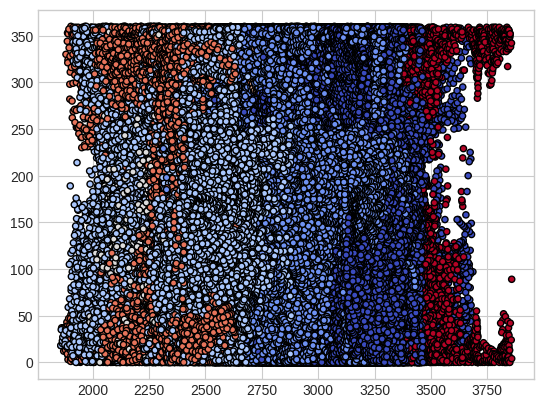

In [ ]:
# 아래 코드는 뻗어버릴수있으니 참고만
### 산림 데이터(covtype) 시각화 시도 :
### 실제 데이터셋의 특성 중 앞의 두 가지(0번, 1번 특징)만 사용하여 분포를 확인

# covtype 데이터의 첫 두 가지 특성(X축: 0번, Y축: 1번 특징)을 기준으로 산점도 시각화
# 데이터가 너무 방대하고 겹쳐 보일 수 있으나 분포의 경향성을 파악하기 위함
#plt.scatter(covtype_X[:, 0], covtype_X[:, 1], c=covtype_y, cmap=plt.cm.coolwarm, s=20, edgecolors='k');

# 베르누이 나이브 베이즈
*   입력 특성이 베르누이 분포에 의해 생성된 이진 값을 갖는다고 가정

## 학습 및 평가(Count)

In [ ]:
### CountVectorizer 데이터 기반 학습 및 평가 :
### 단어의 빈도수를 세었던 데이터를 사용하여 베르누이 모델을 학습시킵니다. 내부적으로 빈도수가 1 이상이면 1, 0이면 0으로 처리됩니다.


# 베르누이 나이브 베이즈 모델 생성 및 학습
model = BernoulliNB()
model.fit(X_train_count, y_train)

BernoulliNB()

In [ ]:
### CountVectorizer 데이터 기반 학습 및 평가 :
### 단어의 빈도수를 세었던 데이터를 사용하여 베르누이 모델을 학습시킵니다. 내부적으로 빈도수가 1 이상이면 1, 0이면 0으로 처리됩니다.


# 학습 데이터 성능 평가
predict = model.predict(X_train_count)
acc = metrics.accuracy_score(y_train, predict)
f1 = metrics.f1_score(y_train, predict, average=None)

print('Train Accuracy: {}'.format(acc))
print('Train F1 score: {}'.format(f1))

Train Accuracy: 0.7821283365741559
Train F1 score: [0.80096502 0.8538398  0.13858268 0.70686337 0.85220126 0.87944493
 0.51627694 0.84532672 0.89064976 0.87179487 0.94561404 0.91331546
 0.84627832 0.89825848 0.9047619  0.79242424 0.84693878 0.84489796
 0.67329545 0.14742015]


In [ ]:
### CountVectorizer 데이터 기반 학습 및 평가 :
### 단어의 빈도수를 세었던 데이터를 사용하여 베르누이 모델을 학습시킵니다. 내부적으로 빈도수가 1 이상이면 1, 0이면 0으로 처리됩니다.


# 평가(Test) 데이터 성능 평가
predict = model.predict(X_test_count)
acc = metrics.accuracy_score(y_test, predict)
f1 = metrics.f1_score(y_test, predict, average=None)

print('Test Accuracy: {}'.format(acc))
print('Test F1 score: {}'.format(f1))

Test Accuracy: 0.6307753584705258
Test F1 score: [0.47086247 0.60643564 0.01       0.56014047 0.6953405  0.70381232
 0.44829721 0.71878646 0.81797753 0.81893491 0.90287278 0.74794521
 0.61647059 0.64174455 0.76967096 0.63555114 0.64285714 0.77971474
 0.31382979 0.00793651]


## 학습 및 평가(Hash)

In [ ]:
### HashingVectorizer 데이터 기반 학습 및 평가 :
### 해시 함수를 통해 고정된 크기(1000)로 변환된 데이터를 사용하여 학습합니다.


# 해시 벡터화 데이터를 이용한 모델 학습
model = BernoulliNB()
model.fit(X_train_hash, y_train)

BernoulliNB()

In [ ]:
### HashingVectorizer 데이터 기반 학습 및 평가 :
### 해시 함수를 통해 고정된 크기(1000)로 변환된 데이터를 사용하여 학습합니다.


# 해시 데이터 - 학습 데이터 성능 평가
predict = model.predict(X_train_hash)
acc = metrics.accuracy_score(y_train, predict)
f1 = metrics.f1_score(y_train, predict, average=None)

print('Train Accuracy: {}'.format(acc))
print('Train F1 score: {}'.format(f1))

Train Accuracy: 0.5951917977726711
Train F1 score: [0.74226804 0.49415205 0.45039019 0.59878155 0.57327935 0.63929619
 0.35390947 0.59851301 0.72695347 0.68123862 0.79809524 0.70532319
 0.54703833 0.66862745 0.61889927 0.74707471 0.6518668  0.60485269
 0.5324165  0.54576271]


In [ ]:
### HashingVectorizer 데이터 기반 학습 및 평가 :
### 해시 함수를 통해 고정된 크기(1000)로 변환된 데이터를 사용하여 학습합니다.


# 해시 데이터 - 평가 데이터 성능 평가
predict = model.predict(X_test_hash)
acc = metrics.accuracy_score(y_test, predict)
f1 = metrics.f1_score(y_test, predict, average=None)

print('Test Accuracy: {}'.format(acc))
print('Test F1 score: {}'.format(f1))

Test Accuracy: 0.4430430164630908
Test F1 score: [0.46678636 0.33826638 0.29391892 0.45743329 0.41939121 0.46540881
 0.34440068 0.46464646 0.62849873 0.53038674 0.63782051 0.55251799
 0.32635983 0.34266886 0.46105919 0.61780105 0.46197991 0.54591837
 0.27513228 0.3307888 ]


## 학습 및 평가(Tf-idf)

In [ ]:
### TF-IDF 데이터 기반 학습 및 평가 :
### 가중치가 적용된 실수형 데이터를 사용합니다. 베르누이 모델은 이 실수값들도 특정 임계값(기본 0.0)을 기준으로 이진화하여 처리합니다.


# TF-IDF 벡터화 데이터를 이용한 모델 학습
model = BernoulliNB()
model.fit(X_train_tfidf, y_train)

BernoulliNB()

In [ ]:
### TF-IDF 데이터 기반 학습 및 평가 :
### 가중치가 적용된 실수형 데이터를 사용합니다. 베르누이 모델은 이 실수값들도 특정 임계값(기본 0.0)을 기준으로 이진화하여 처리합니다.


# TF-IDF 데이터 - 학습 데이터 성능 평가
predict = model.predict(X_train_tfidf)
acc = metrics.accuracy_score(y_train, predict)
f1 = metrics.f1_score(y_train, predict, average=None)

print('Train Accuracy: {}'.format(acc))
print('Train F1 score: {}'.format(f1))

Train Accuracy: 0.7821283365741559
Train F1 score: [0.80096502 0.8538398  0.13858268 0.70686337 0.85220126 0.87944493
 0.51627694 0.84532672 0.89064976 0.87179487 0.94561404 0.91331546
 0.84627832 0.89825848 0.9047619  0.79242424 0.84693878 0.84489796
 0.67329545 0.14742015]


In [ ]:
### TF-IDF 데이터 기반 학습 및 평가 :
### 가중치가 적용된 실수형 데이터를 사용합니다. 베르누이 모델은 이 실수값들도 특정 임계값(기본 0.0)을 기준으로 이진화하여 처리합니다.


# TF-IDF 데이터 - 평가 데이터 성능 평가
predict = model.predict(X_test_tfidf)
acc = metrics.accuracy_score(y_test, predict)
f1 = metrics.f1_score(y_test, predict, average=None)

print('Test Accuracy: {}'.format(acc))
print('Test F1 score: {}'.format(f1))

Test Accuracy: 0.6307753584705258
Test F1 score: [0.47086247 0.60643564 0.01       0.56014047 0.6953405  0.70381232
 0.44829721 0.71878646 0.81797753 0.81893491 0.90287278 0.74794521
 0.61647059 0.64174455 0.76967096 0.63555114 0.64285714 0.77971474
 0.31382979 0.00793651]


## 시각화

In [ ]:
### 가상 데이터 시각화 (베르누이 모델의 결정 경계) :
### 연속적인 공간에서 베르누이 모델이 어떻게 데이터를 이진화하여 분류하는지 시각적으로 확인


# 가상의 데이터 덩어리 생성
X, y = make_blobs(n_samples=1000)

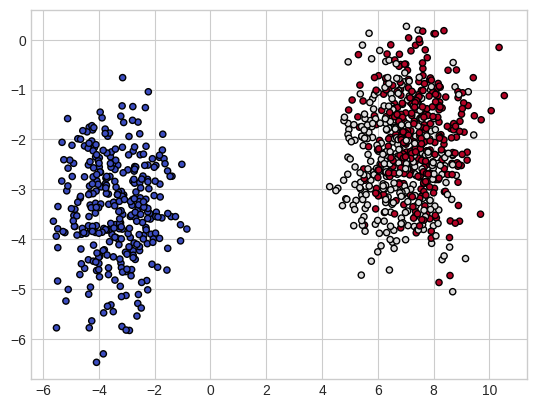

In [ ]:
### 가상 데이터 시각화 (베르누이 모델의 결정 경계) :
### 연속적인 공간에서 베르누이 모델이 어떻게 데이터를 이진화하여 분류하는지 시각적으로 확인


# 데이터의 초기 분포를 산점도로 확인
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=20, edgecolors='k');

In [ ]:
### 가상 데이터 시각화 (베르누이 모델의 결정 경계) :
### 연속적인 공간에서 베르누이 모델이 어떻게 데이터를 이진화하여 분류하는지 시각적으로 확인


# 베르누이 모델로 학습
# BernoulliNB는 원래 이진 특성에 적합하지만, 실수값 데이터도 학습이 가능합니다.
model = BernoulliNB()
model.fit(X, y)

BernoulliNB()

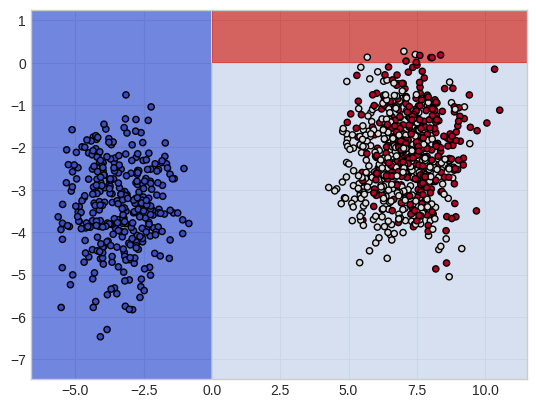

In [ ]:
### 가상 데이터 시각화 (베르누이 모델의 결정 경계) :
### 연속적인 공간에서 베르누이 모델이 어떻게 데이터를 이진화하여 분류하는지 시각적으로 확인


# 결정 경계 시각화
# 베르누이 모델 특성상 특정 기준값을 중심으로 수직/수평적인 직선의 조합으로 경계가 생기는 경향이 있습니다.
xx, yy = make_meshgrid(X[:, 0], X[:, 1])
plot_contours(model, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=20, edgecolors='k');

# 다항 나이브 베이즈
*   입력 특성이 다항분포에 의해 생성된 빈도수 값을 갖는다고 가정

## 학습 및 평가 (Count)

In [ ]:
### Count 기반 데이터 학습 및 모델 생성 :
### 이 섹션은 텍스트를 단순히 "단어가 몇 번 나왔는가"라는 빈도수(Count) 데이터로 변환하여 모델을 학습


# 1. 모델 객체 생성
model = MultinomialNB()
# 사용 이유: 'MultinomialNB'는 다항 나이브 베이즈 모델로, 텍스트 분류(스팸 메일 분류 등)에 특화되어 있습니다.
# 함수 사용법: 매개변수 없이 호출하면 기본값으로 생성되며, 데이터의 출현 횟수를 기반으로 확률을 계산합니다.

# 2. 모델 학습 (Fitting)
model.fit(X_train_count, y_train)
# 사용 이유: 기계가 데이터(X)와 정답(y) 사이의 관계를 배우도록 합니다.
# 함수 사용법: fit(학습데이터, 정답라벨) 순서로 입력합니다.

MultinomialNB()

In [ ]:
### 학습 데이터(Train)를 통한 모델 성능 검증 :
### 모델이 자기가 배운 데이터를 얼마나 잘 기억하고 있는지 확인하는 단계


# 1. 예측값 생성
predict = model.predict(X_train_count)
# 사용 이유: 학습한 모델이 훈련 데이터를 어떻게 예측하는지 확인하여 학습이 잘 되었는지 판단합니다.
# 함수 사용법: predict(데이터)를 넣으면 모델이 예측한 정답 리스트를 반환합니다.

# 2. 정확도(Accuracy) 계산
acc = metrics.accuracy_score(y_train, predict)
# 사용 이유: 전체 데이터 중 맞춘 비율을 계산합니다. 가장 직관적인 지표입니다.

# 3. F1-Score 계산
f1 = metrics.f1_score(y_train, predict, average=None)
# 사용 이유: 데이터가 특정 클래스에 쏠려 있을 때 정확도의 함정을 피하기 위해 정밀도와 재현율을 결합한 지표입니다.
# 함수 사용법: average=None을 설정하면 각 클래스별 점수를 각각 보여줍니다.

print('Train Accuracy: {}'.format(acc))
print('Train F1 score: {}'.format(f1))

Train Accuracy: 0.9245182959165635
Train F1 score: [0.95228426 0.904      0.25073746 0.81402003 0.96669513 0.88350983
 0.90710383 0.97014925 0.98567818 0.99325464 0.98423237 0.95399516
 0.95703454 0.98319328 0.98584513 0.95352564 0.97307002 0.97467249
 0.95157895 0.86526946]


In [ ]:
### 테스트 데이터(Test)를 통한 실전 성능 평가 :
### 한 번도 보지 못한 새로운 데이터(Test set)에서도 모델이 잘 작동하는지(일반화 성능)를 확인


# 테스트 데이터 예측 및 평가 (함수 사용법은 위와 동일)
predict = model.predict(X_test_count)
acc = metrics.accuracy_score(y_test, predict)
f1 = metrics.f1_score(y_test, predict, average=None)

print('Test Accuracy: {}'.format(acc))
print('Test F1 score: {}'.format(f1))
# 의미: 훈련 점수보다 테스트 점수가 너무 낮다면 '과적합(Overfitting)'을 의심해볼 수 있습니다.

Train Accuracy: 0.7728359001593202
Train F1 score: [0.77901431 0.7008547  0.00501253 0.64516129 0.79178082 0.73370166
 0.76550681 0.88779285 0.93951094 0.91390728 0.94594595 0.78459938
 0.72299169 0.84635417 0.86029412 0.80846561 0.78665077 0.89281211
 0.60465116 0.48695652]


## 학습 및 평가 (Tf-idf)

In [ ]:
### TF-IDF 기반 데이터 학습 :
### 단순 빈도수가 아닌, 단어의 희소성(중요도)을 고려한
### TF-IDF(Term Frequency-Inverse Document Frequency) 데이터를 사용하여 학습


model = MultinomialNB()
model.fit(X_train_tfidf, y_train)
# 사용 이유: "the", "a" 처럼 자주 나오지만 의미 없는 단어의 힘은 빼고, 특정 문서에만 등장하는 중요한 단어의 힘을 실어주기 위함입니다.

MultinomialNB()

In [ ]:
### TF-IDF 학습 및 테스트 데이터 평가 :
### TF-IDF 방식을 썼을 때 빈도수 방식(Count)보다 성능이 좋아졌는지 비교하는 과정


predict = model.predict(X_train_tfidf)
acc = metrics.accuracy_score(y_train, predict)
f1 = metrics.f1_score(y_train, predict, average=None)

print('Train Accuracy: {}'.format(acc))
print('Train F1 score: {}'.format(f1))

Train Accuracy: 0.9326498143892522
Train F1 score: [0.87404162 0.95414462 0.95726496 0.92863002 0.97812773 0.97440273
 0.91090909 0.97261411 0.98659966 0.98575021 0.98026316 0.94033413
 0.9594478  0.98032506 0.97755611 0.77411003 0.93506494 0.97453907
 0.90163934 0.45081967]


In [ ]:
### TF-IDF 학습 및 테스트 데이터 평가 :
### TF-IDF 방식을 썼을 때 빈도수 방식(Count)보다 성능이 좋아졌는지 비교하는 과정


predict = model.predict(X_test_tfidf)
acc = metrics.accuracy_score(y_test, predict)
f1 = metrics.f1_score(y_test, predict, average=None)

print('Test Accuracy: {}'.format(acc))
print('Test F1 score: {}'.format(f1))

Train Accuracy: 0.7738980350504514
Train F1 score: [0.63117871 0.72       0.72778561 0.72104019 0.81309686 0.81643836
 0.7958884  0.88135593 0.93450882 0.91071429 0.92917167 0.73583093
 0.69732938 0.81907433 0.86559803 0.60728118 0.76286353 0.92225201
 0.57977528 0.24390244]


## 시각화

In [ ]:
### 가상 데이터 생성 및 스케일링 (시각화 준비)
### 모델이 어떻게 공간을 나누는지 눈으로 보기 위해 가짜 데이터를 만들고 전처리합니다.


# 1. 가상 데이터 생성
X, y = make_blobs(n_samples=1000)
# 사용 이유: 실제 데이터 분석 전에 모델의 특성을 파악하기 위해 인위적인 덩어리(blobs) 데이터를 만듭니다.

In [ ]:
### 가상 데이터 생성 및 스케일링 (시각화 준비)
### 모델이 어떻게 공간을 나누는지 눈으로 보기 위해 가짜 데이터를 만들고 전처리합니다.


# 2. 데이터 범위 조정 (Scaling)
scaler = MinMaxScaler()
X = scaler.fit_transform(X)
# 사용 이유: MultinomialNB 모델은 '음수' 데이터를 처리할 수 없습니다.
# 함수 사용법: MinMaxScaler는 모든 데이터를 0과 1 사이로 변환하여 모델이 오류 없이 돌아가게 합니다.

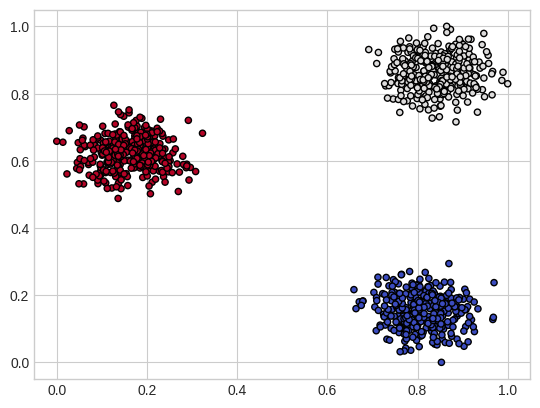

In [ ]:
### 데이터 분포 시각화 :
### 학습 전 데이터가 좌표 평면상에 어떻게 퍼져 있는지 확인


plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=20, edgecolors='k');
# 사용 이유: x축(첫 번째 특성), y축(두 번째 특성)을 기준으로 데이터의 위치를 점으로 찍어 분포를 확인합니다.
# 매개변수: c=y는 정답(클래스)에 따라 색상을 다르게 칠하라는 뜻입니다.

In [ ]:
### MultinomialNB으로 재학습

# 1. 모델 재학습
model = MultinomialNB()
model.fit(X, y)

MultinomialNB()

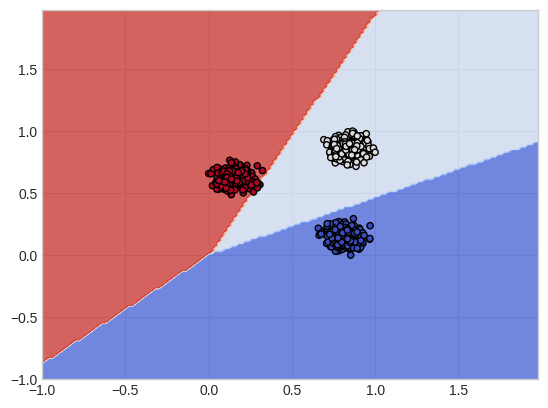

In [ ]:
### 결정 경계(Decision Boundary) 확인 :
### 마지막으로 모델이 데이터를 어떻게 구분하고 있는지 경계선을 그려봅니다.


# 2. 결정 경계 그리기
xx, yy = make_meshgrid(X[:, 0], X[:, 1]) # 좌표 평면을 촘촘한 격자로 나눕니다.
plot_contours(model, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8) # 모델이 예측한 영역별로 색을 칠합니다.
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=20, edgecolors='k'); # 그 위에 실제 데이터를 뿌립니다.
# 의미: 배경 색상(모델의 예측)과 점의 색상(실제 정답)이 일치하는 영역이 많을수록 좋은 모델입니다.